# KMeans RFM Customer Segmentation

Exploratory analysis and training notebook for KMeans-based customer segmentation using **RFM** (Recency, Frequency, Monetary) features.

| | |
|---|---|
| **Dataset** | Olist E-commerce (2016–2018) |
| **Training period** | 2016-09-04 → 2017-02-28 |
| **Algorithm** | KMeans with RobustScaler |
| **Segments** | Active Buyers · High Value · Cooling Down · Dormant |

In [1]:
from dotenv import load_dotenv
from os import getenv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import yaml

In [11]:
import sys
from pathlib import Path

# Load project root directory into sys.path
notebook_dir = Path().resolve()
print(f"Notebook directory: {notebook_dir}")
project_root = str(notebook_dir.parents[3])
print(f"Project root directory: {project_root}")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added {project_root} to sys.path: {sys.path}")

# Import the KMeans module after updating sys.path
from plugins.services.ml.kmeans import *

Notebook directory: D:\FPTU_Education\olist-capstone-workspace\airflow-server\plugins\services\ml\notebooks
Project root directory: D:\FPTU_Education\olist-capstone-workspace\airflow-server


## 1. Configuration & Database Connection

Load training parameters from `contexts/kmeans_rfm_training.yaml` and connect to PostgreSQL via SQLAlchemy.

In [12]:
# Load configuration from YAML file
config = yaml.safe_load(open(sys.path[0] + r'\contexts\kmeans_rfm_training.yaml'))

training_schema = config['postgres']['training']['schema']
training_table = config['postgres']['training']['table']
start_date = config['postgres']['training']['start_date']
end_date = config['postgres']['training']['end_date']
snapshot_date = config['postgres']['training']['snapshot_date']
window_days = config['postgres']['training']['window_days']
n_clusters = config['postgres']['training']['n_clusters']
training_query = config['postgres']['training']['query']

# load environment variables
load_dotenv()
database = getenv("DATABASE")
user = getenv("USER")
password = getenv("PASSWORD")
host = getenv("HOST")
port = getenv("PORT")
supabase_url = getenv("SUPABASE_URL")
supabase_key = getenv("SUPABASE_KEY")

## 2. Data Extraction

Extract RFM features from the database for the training period.

| Feature | Description |
|---|---|
| **Recency** | Days since last purchase relative to `end_date` |
| **Frequency** | Number of distinct orders |
| **Monetary** | Total payment value (BRL) |

In [13]:
# Create engine and extract data
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')
df = extract_data(engine, training_query, start_date=start_date, end_date=end_date)
df.head()

,customer_unique_id,event_date,revenue
0,00115fc7123b5310cf6d3a3aa932699e,2017-01-21,76.11
1,002b4cd83fabaffaa475f78ea5ef3e08,2017-02-01,64.42
2,0032c76b20340da25249092a268ce66c,2016-10-06,144.94
3,0087eede471173af78d789df249c3a45,2017-02-16,151.11
4,008f3d5f45a11059239a5c452cd00006,2017-01-26,336.56


## 3. RFM Computation

Compute **Recency**, **Frequency**, and **Monetary** features per customer from raw order data.

| Feature | Window | Description |
|---|---|---|
| **Recency** | Full period | Days since last purchase relative to `snapshot_date` |
| **Frequency** | Last 60 days | Number of orders within the 60-day window |
| **Monetary** | Last 60 days | Total revenue within the 60-day window |

Customers who bought outside the 60-day window receive Frequency = 0, Monetary = 0 — they become the **Cooling Down** and **Dormant** segments.

In [14]:
print(f"Rows loaded: {len(df):,}")
print(f"Unique users: {df['customer_unique_id'].nunique():,}")
print(f"Date range: {df['event_date'].min()} → {df['event_date'].max()}")

Rows loaded: 2,748
Unique users: 2,734
Date range: 2016-09-04 → 2017-02-28


In [16]:
window_start = snapshot_date - pd.Timedelta(days=60)
df_window = df[df['event_date'] >= window_start].copy()

print(f"Snapshot date: {snapshot_date}")
print(f"Window start: {window_start}")
print(f"Window end: {snapshot_date}")
print(f"Window days: {window_days}")

Snapshot date: 2017-02-28
Window start: 2016-12-30
Window end: 2017-02-28
Window days: 60


In [30]:
# All unique users in the full dataset
all_users = df[['customer_unique_id']].drop_duplicates()

# Recency
recency_df = (
    df
    .groupby('customer_unique_id')['event_date']
    .max()
    .reset_index()
    .rename(columns={'event_date': 'last_order_date'})
)
snapshot_date = pd.to_datetime(snapshot_date)
recency_df['last_order_date'] = pd.to_datetime(recency_df['last_order_date'])
recency_df['recency'] = (snapshot_date - recency_df['last_order_date']).dt.days

# Frequency 60d
rfm_60d = (
    df_window
    .groupby('customer_unique_id')
    .agg(
        freq_60d=('event_date', 'count'),
        monetary_60d=('revenue', 'sum')
    )
)

# final df
rfm = (
    all_users
    .merge(recency_df[['customer_unique_id', 'recency']], on='customer_unique_id', how='left')
    .merge(rfm_60d, on='customer_unique_id', how='left')
)

# fillna
rfm['freq_60d'] = rfm['freq_60d'].fillna(0).astype(int)
rfm['monetary_60d'] = rfm['monetary_60d'].fillna(0.0)

rfm['snapshot_date'] = snapshot_date.date()

print(f"RFM users total: {len(rfm):,}")
print(f"Users với freq=0: {(rfm['freq_60d'] == 0).sum():,} ({(rfm['freq_60d'] == 0).mean():.1%})")
rfm.head(10)

RFM users total: 2,734
Users với freq=0: 291 (10.6%)


,customer_unique_id,recency,freq_60d,monetary_60d,snapshot_date
0,00115fc7123b5310cf6d3a3aa932699e,38,1,76.11,2017-02-28
1,002b4cd83fabaffaa475f78ea5ef3e08,27,1,64.42,2017-02-28
2,0032c76b20340da25249092a268ce66c,145,0,0.0,2017-02-28
3,0087eede471173af78d789df249c3a45,12,1,151.11,2017-02-28
4,008f3d5f45a11059239a5c452cd00006,33,1,336.56,2017-02-28
5,012b8001e47392df808a454083a74b74,18,1,98.84,2017-02-28
6,012e12f54f6e73b1faba89a119dab849,30,1,105.74,2017-02-28
7,01469c41b00bb21cd01d2104b8e81384,17,1,111.01,2017-02-28
8,016feebfaba953a2456d3a063b8eb8ef,15,1,62.83,2017-02-28
9,01838e7d69d87bd8ff2b6ff06789adfb,38,1,159.11,2017-02-28


In [31]:
print(rfm[['recency', 'freq_60d', 'monetary_60d']].describe().round(2))
print(f"\nNull check:")
print(rfm.isnull().sum())

       recency  freq_60d
count  2734.00   2734.00
mean     34.46      0.90
std      39.82      0.32
min       0.00      0.00
25%      13.00      1.00
50%      23.00      1.00
75%      34.00      1.00
max     177.00      2.00

Null check:
customer_unique_id    0
recency               0
freq_60d              0
monetary_60d          0
snapshot_date         0
dtype: int64


## 4. Feature Engineering

- Apply `log1p` transform to both `freq_60d` and `monetary_60d` to reduce right skew
- Scale all 3 features using `RobustScaler` (median + IQR) — robust to outliers
- Visualise distributions before scaling to verify transformation quality

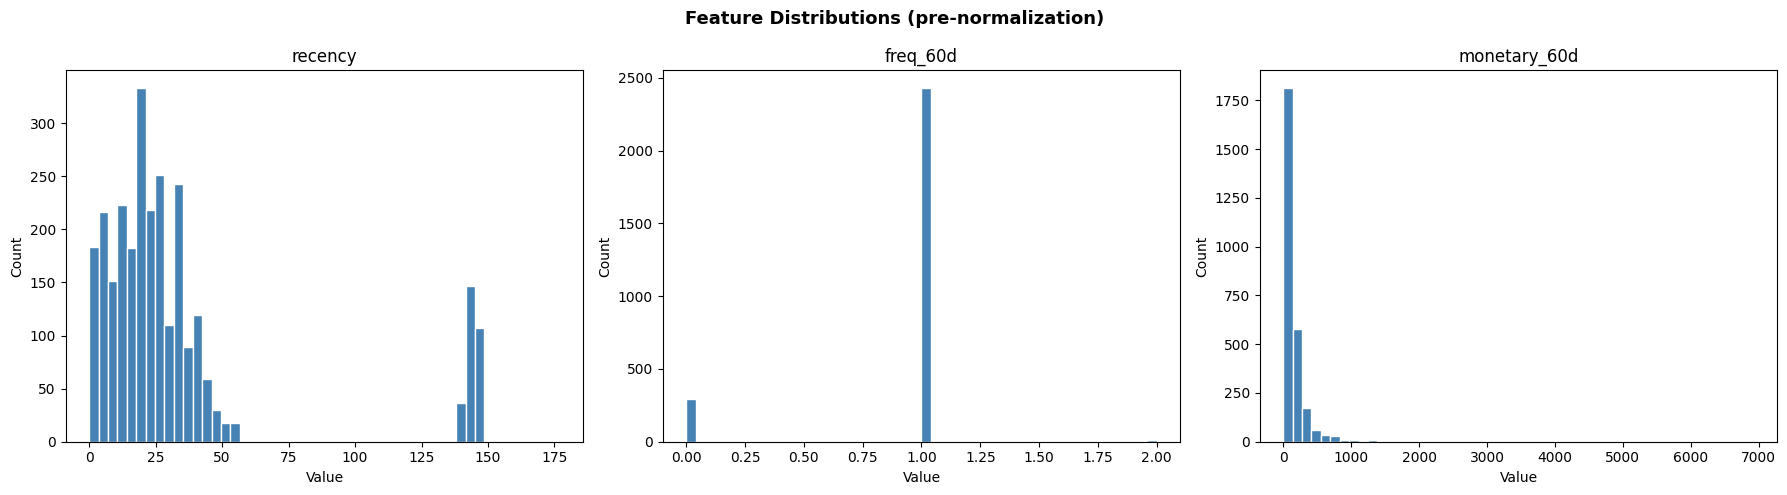

In [32]:
# Pre normalization distribution  
pre_norm = rfm[['recency', 'freq_60d', 'monetary_60d']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(pre_norm):
    axes[i].hist(rfm[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions (pre-normalization)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
rfm['log_freq_60d'] = np.log1p(rfm['freq_60d'])
rfm['log_monetary_60d'] = np.log1p(rfm['monetary_60d'].astype(float))

features = ['recency', 'log_freq_60d', 'log_monetary_60d']
x = rfm[features].values

print(f"Features used: {features}")
print(f"Feature matrix shape: {x.shape}")
print(x[:5])  # Print first 5 rows

Features used: ['recency', 'log_freq_60d', 'log_monetary_60d']
Feature matrix shape: (2734, 3)
[[ 38.           0.69314718   4.34523297]
 [ 27.           0.69314718   4.18082802]
 [145.           0.           0.        ]
 [ 12.           0.69314718   5.02460394]
 [ 33.           0.69314718   5.82174327]]


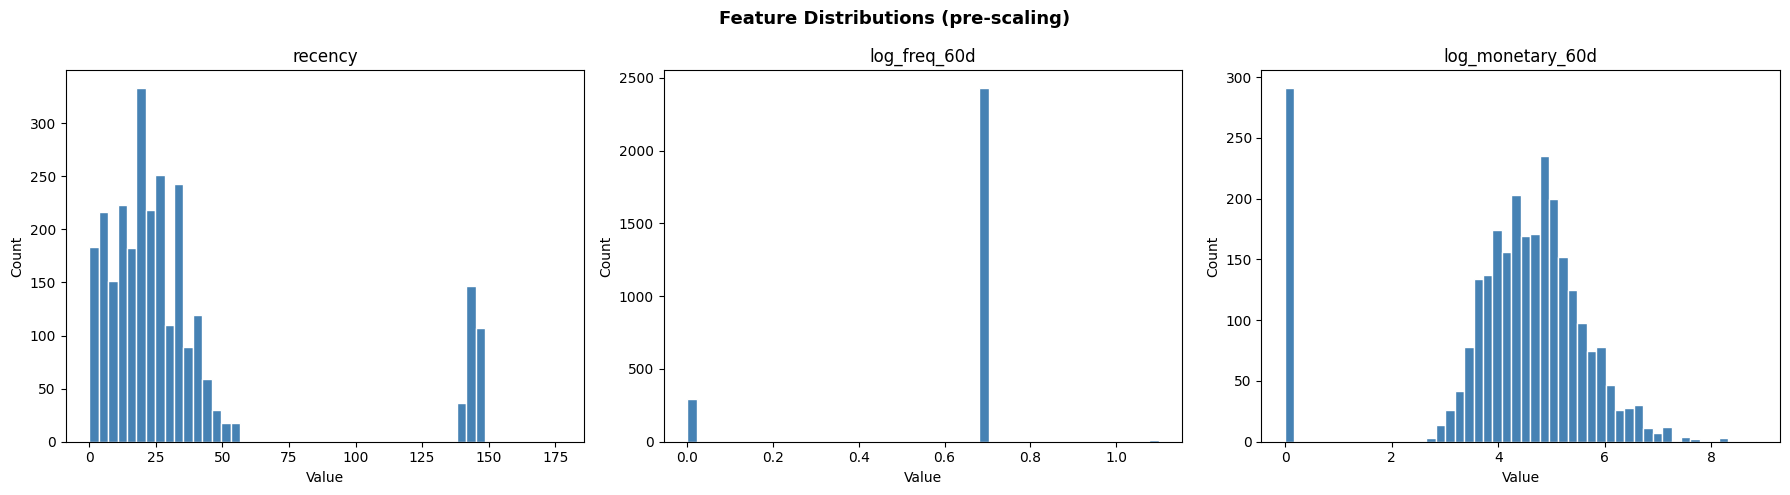

In [21]:
# distribution of features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features):
    axes[i].hist(rfm[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Feature Distributions (pre-scaling)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# scale features
scaler = RobustScaler()
x_scaled = scaler.fit_transform(x)

print("Scaled feature stats:")
print(pd.DataFrame(x_scaled, columns=features).describe().round(3))

Scaled feature stats:
        recency  log_freq_60d  log_monetary_60d
count  2734.000      2734.000          2734.000
mean      0.546        -0.072            -0.242
std       1.896         0.216             1.274
min      -1.095        -0.693            -3.465
25%      -0.476         0.000            -0.529
50%       0.000         0.000             0.000
75%       0.524         0.000             0.471
max       7.333         0.405             3.298


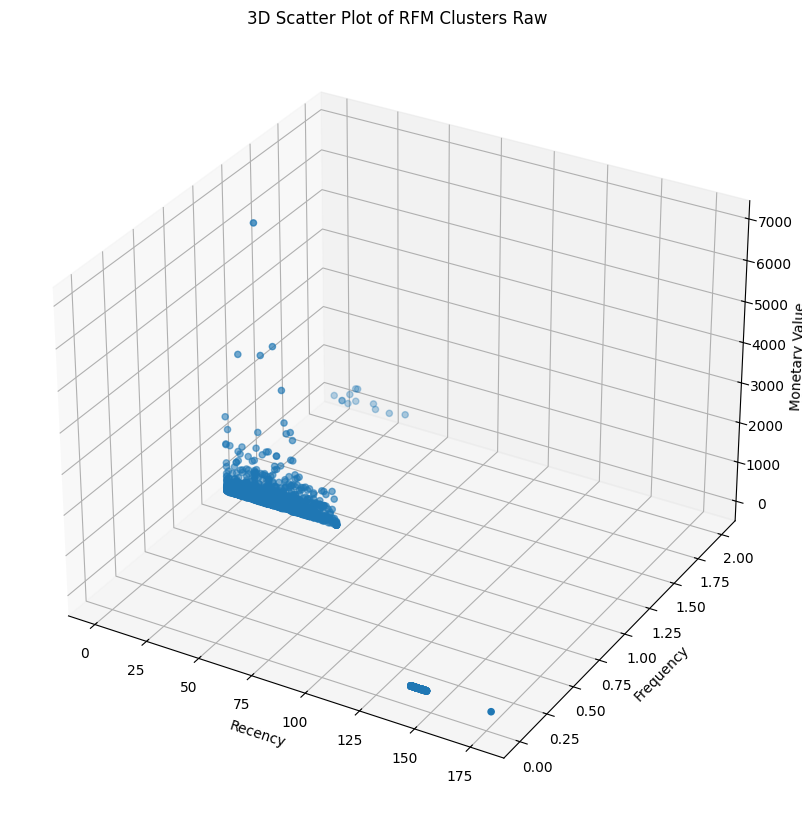

In [42]:
# 3D Scatter Plot of RFM Clusters Raw
df_scaled = pd.DataFrame(pre_norm, columns=['recency', 'freq_60d', 'monetary_60d'])

fig = plt.figure(figsize=(10, 18))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['recency'].astype(float),
    df_scaled['freq_60d'].astype(float),
    df_scaled['monetary_60d'].astype(float)
)

ax.set_zlabel('Monetary Value')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')

ax.set_title('3D Scatter Plot of RFM Clusters Raw')

plt.show()

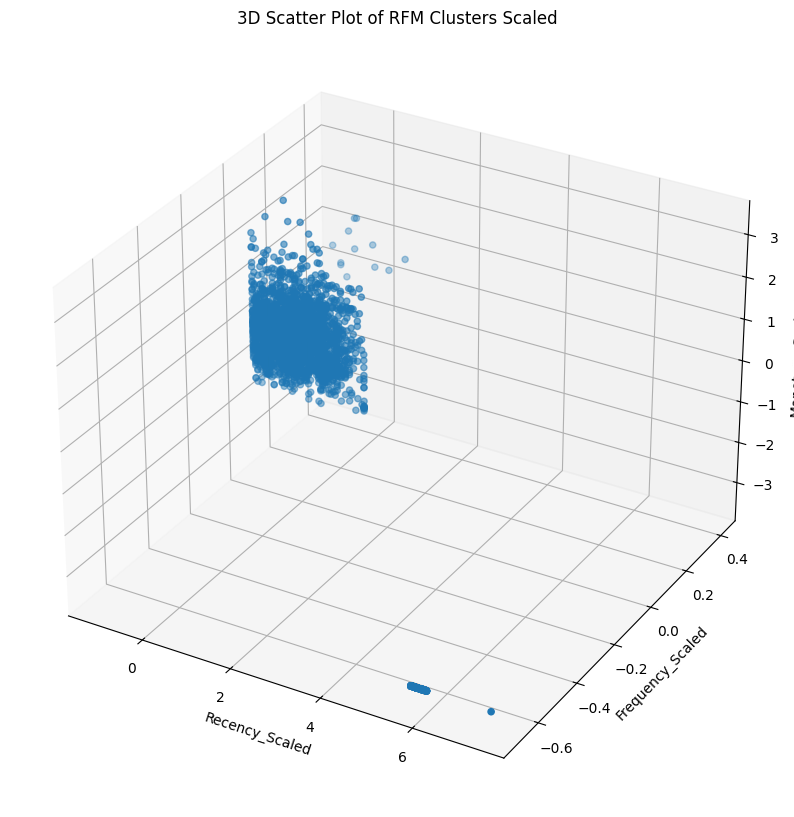

In [43]:
# 3D Scatter Plot of RFM Clusters Scaled
df_scaled = pd.DataFrame(x_scaled, columns=['recency', 'log_freq_60d', 'log_monetary_60d'])

fig = plt.figure(figsize=(10, 18))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['recency'].astype(float),
    df_scaled['log_freq_60d'].astype(float),
    df_scaled['log_monetary_60d'].astype(float)
)

ax.set_zlabel('Monetary_Scaled')
ax.set_xlabel('Recency_Scaled')
ax.set_ylabel('Frequency_Scaled')

ax.set_title('3D Scatter Plot of RFM Clusters Scaled')

plt.show()

## 5. Finding Optimal k — Elbow Method & Silhouette Score

Evaluate `k` from 2 to 7 on **scaled data** using two metrics:

| Metric | What to look for |
|---|---|
| **Inertia (Elbow)** | Point where inertia starts decreasing slowly — the "elbow" |
| **Silhouette Score** | Higher = better cluster separation (range: -1 to 1) |

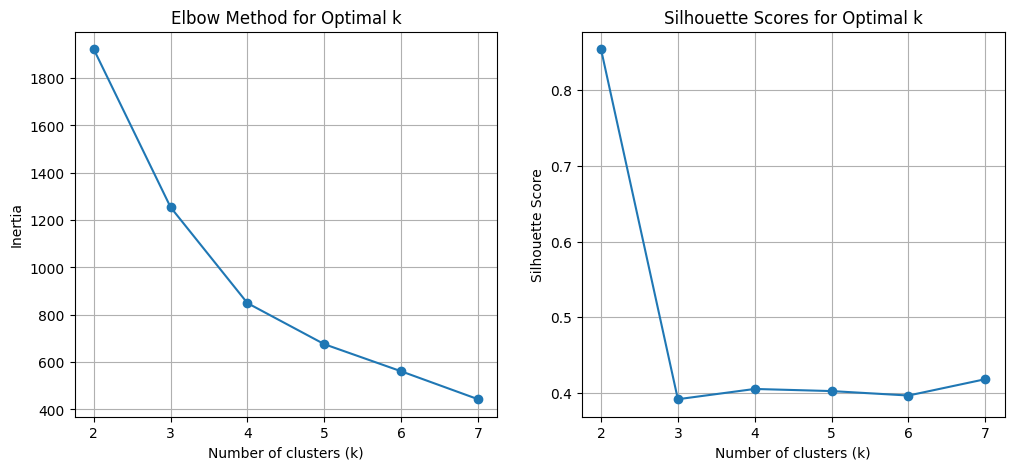

In [46]:
# Elbow Method
from sklearn.cluster import KMeans

inertia = []
silhouette_scores = []
for k in range (2, 8):
    # Fit KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)

    # Append inertia
    inertia.append(kmeans.inertia_)

    # Calculate silhouette score
    sil = silhouette_score(x_scaled, labels)
    silhouette_scores.append(sil)

# Plot inertia
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 8), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(2, 8), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()

plt.show()

## 6. Model Training

Train KMeans với `n_clusters=4` trên scaled RFM data.  
Segment labels được gán dựa trên **recency** và **monetary** của từng centroid — recency phân tách nhóm inactive, monetary phân tách nhóm high value trong tập active.

| Cluster | Segment | Recency | Freq 60d | Monetary 60d |
|---|---|---|---|---|
| **2** | **active_buyers** | thấp (~12d) | > 0 | trung bình (~70 BRL) |
| **3** | **high_value** | thấp–trung (~21d) | > 0 | cao (~252 BRL) |
| **0** | **cooling_down** | trung (~33d) | > 0 | thấp–trung (~77 BRL) |
| **1** | **dormant** | cao (~145d) | 0 | 0 |

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
labels = kmeans.fit_predict(x_scaled)
rfm['cluster'] = labels
df_scaled['cluster'] = labels
final_silhouette = silhouette_score(x_scaled, rfm['cluster'], sample_size=5000)
print(f"Final silhouette score for k=4: {final_silhouette:.4f}")
print(f"Cluster distribution:")
print(rfm['cluster'].value_counts().sort_index())

Final silhouette score for k=4: 0.4095
Cluster distribution:
cluster
0    707
1    291
2    958
3    778
Name: count, dtype: int64


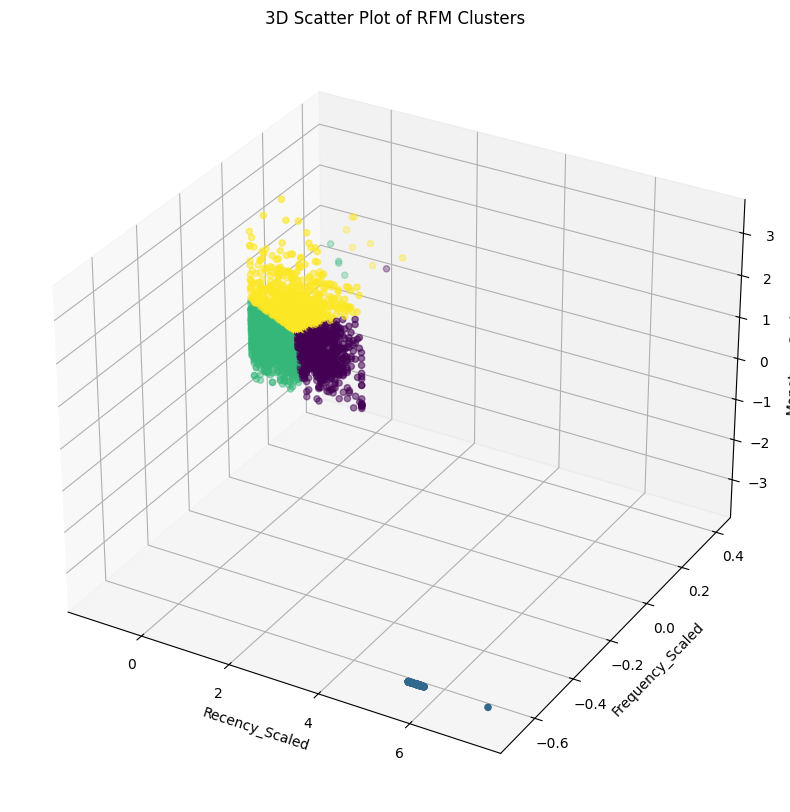

In [48]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    df_scaled['recency'].astype(float),
    df_scaled['log_freq_60d'].astype(float),
    df_scaled['log_monetary_60d'].astype(float),
    c=rfm['cluster'], cmap='viridis', marker='o'
)

ax.set_zlabel('Monetary_Scaled')
ax.set_xlabel('Recency_Scaled')
ax.set_ylabel('Frequency_Scaled')
ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

In [49]:
df_scaled.head()

,recency,log_freq_60d,log_monetary_60d,cluster
0,0.714286,0.000000,-0.141885,0
1,0.190476,0.000000,-0.267610,0
2,5.809524,-0.693147,-3.464797,1
3,-0.523810,0.000000,0.377648,2
4,0.476190,0.000000,0.987241,3


In [51]:
scaled_profile = (
    df_scaled
    .groupby('cluster')
    .agg(
        recency_med=('recency', 'median'),
        min_recency = ('recency', 'min'),
        freq_med=('log_freq_60d', 'median'),
        monetary_med=('log_monetary_60d', 'median'),
        monetary_avg = ('log_monetary_60d', 'mean'),
        max_monetary = ('log_monetary_60d', 'max')
    ).round(2)
)
print(scaled_profile.to_string())

         recency_med  min_recency  freq_med  monetary_med  monetary_avg  max_monetary
cluster                                                                              
0               0.48         0.00      0.00         -0.14         -0.15          0.90
1               5.81         5.62     -0.69         -3.46         -3.46         -3.46
2              -0.52        -1.10      0.00         -0.20         -0.23          0.63
3              -0.10        -1.10      0.00          0.77          0.87          3.30


## 7. Cluster Analysis & Segment Profiles

Profile từng cluster theo raw RFM và map sang tên segment business.

| Cluster | Segment | Recency (med) | Freq 60d | Monetary 60d (med) | % Users | MKT Strategy |
|---|---|---|---|---|---|---|
| **2** | **active_buyers** | ~12d | 1 | ~70 BRL | 35% | Retention · Cross-sell · Loyalty |
| **3** | **high_value** | ~21d | 1 | ~252 BRL | 28% | VIP perks · Upsell · Exclusive offers |
| **0** | **cooling_down** | ~33d | 1 | ~77 BRL | 26% | Win-back · Limited-time offer · Re-engage |
| **1** | **dormant** | ~145d | 0 | 0 BRL | 11% | Last-chance discount · Suppress |

In [52]:
profile = (
    rfm
    .groupby('cluster')
    .agg(
        n_user=('customer_unique_id', 'count'),
        recency_med=('recency', 'median'),
        min_recency = ('recency', 'min'),
        max_recency = ('recency', 'max'),
        freq_med=('freq_60d', 'median'),
        monetary_med=('monetary_60d', 'median'),
        monetary_avg = ('monetary_60d', 'mean'),
        max_monetary = ('monetary_60d', 'max'),
        min_monetary = ('monetary_60d', 'min')
    ).round(2)
)
profile['distribution_user(%)'] = (profile['n_user'] / len(rfm) * 100).round(2)
print(profile.to_string())

         n_user  recency_med  min_recency  max_recency  freq_med monetary_med monetary_avg max_monetary min_monetary  distribution_user(%)
cluster                                                                                                                                   
0           707         33.0           23           54       1.0        76.66    87.088614       301.78        14.86                 25.86
1           291        145.0          141          177       0.0          0.0          0.0          0.0          0.0                 10.64
2           958         12.0            0           24       1.0       70.345    77.025992       211.91        16.96                 35.04
3           778         21.0            0           53       1.0      251.825   366.666003      6929.31       123.34                 28.46


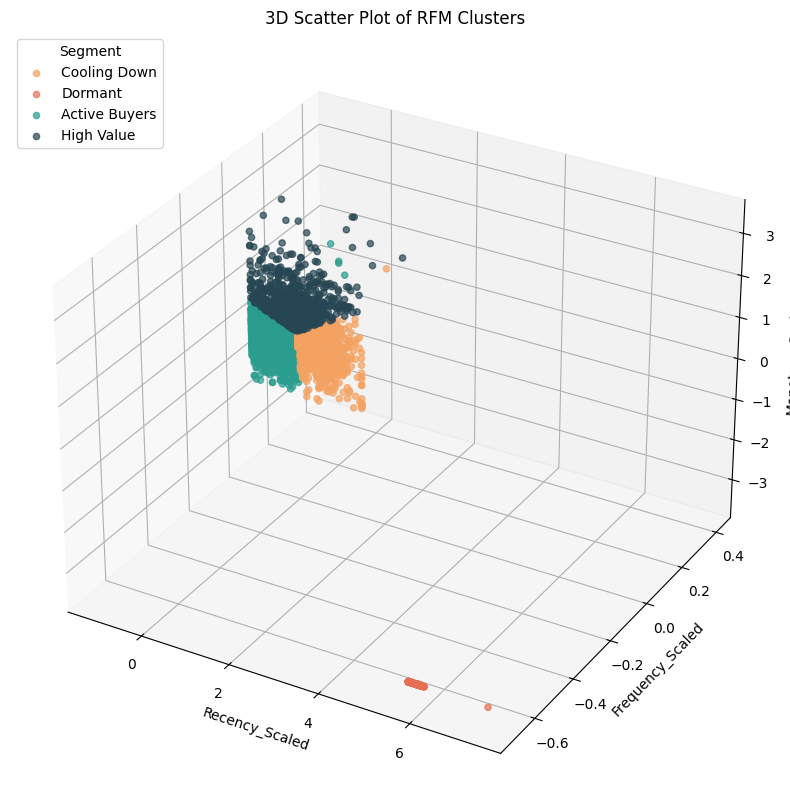

In [55]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

segment_map = {
    0: 'Cooling Down',
    1: 'Dormant',
    2: 'Active Buyers',
    3: 'High Value',
}
colors = {0: '#f4a261', 1: '#e76f51', 2: '#2a9d8f', 3: '#264653'}

for cluster_id, label in segment_map.items():
    mask = rfm['cluster'] == cluster_id
    ax.scatter(
        df_scaled.loc[mask, 'recency'].astype(float),
        df_scaled.loc[mask, 'log_freq_60d'].astype(float),
        df_scaled.loc[mask, 'log_monetary_60d'].astype(float),
        c=colors[cluster_id],
        marker='o',
        label=label,
        alpha=0.7
    )

ax.set_xlabel('Recency_Scaled')
ax.set_ylabel('Frequency_Scaled')
ax.set_zlabel('Monetary_Scaled')
ax.set_title('3D Scatter Plot of RFM Clusters')
ax.legend(title='Segment', loc='upper left', bbox_to_anchor=(0.0, 1.0))

plt.show()


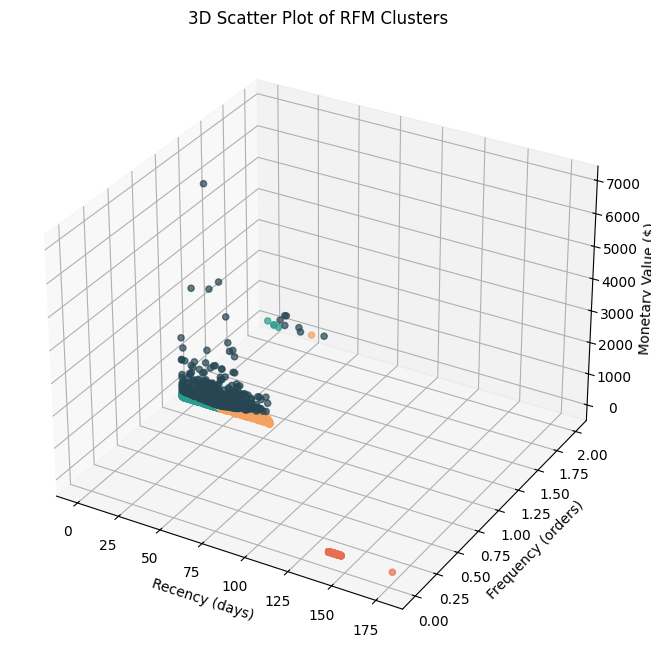

In [ ]:
# 3D Scatter Plot of RFM Clusters
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

segment_map = {
    0: 'Cooling Down',
    1: 'Dormant',
    2: 'Active Buyers',
    3: 'High Value',
}
colors = {0: '#f4a261', 1: '#e76f51', 2: '#2a9d8f', 3: '#264653'}

for cluster_id, label in segment_map.items():
    mask = rfm['cluster'] == cluster_id
    scatter = ax.scatter(
        rfm.loc[mask, 'recency'].astype(float),
        rfm.loc[mask, 'freq_60d'].astype(float),
        rfm.loc[mask, 'monetary_60d'].astype(float),
        c=colors[cluster_id],
        marker='o',
        label=label,
        alpha=0.7
    )

ax.set_zlabel('Monetary Value ($)')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')

ax.set_title('3D Scatter Plot of RFM Clusters')

plt.show()

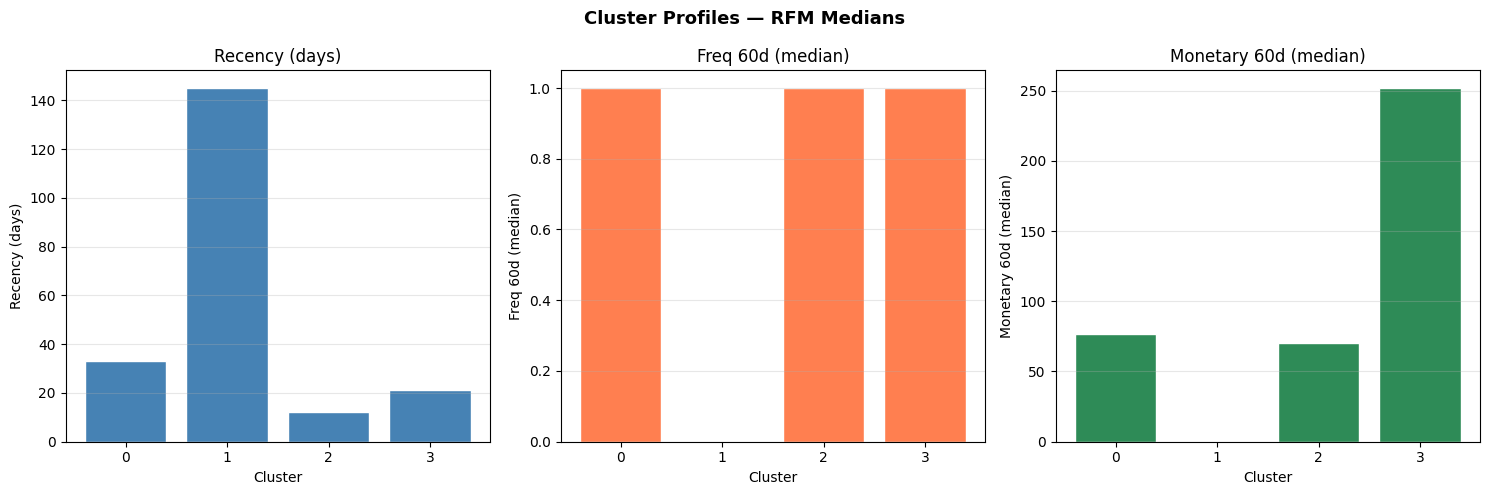

In [53]:
# visualize cluster profiles
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ('recency_med',  'Recency (days)',    'steelblue'),
    ('freq_med',     'Freq 60d (median)', 'coral'),
    ('monetary_med', 'Monetary 60d (median)', 'seagreen'),
]
for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(profile.index.astype(str), profile[col], color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Profiles — RFM Medians', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
rfm.head()